# Amazon Sales Report - Python Analysis

**Total Data: 128.9K** | Dataset from Kaggle | E-Commerce Sales Analysis

## 1. Import Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'figure.dpi': 100
})

PALETTE = ['#FF9900', '#232F3E', '#37475A', '#146EB4', '#E47911',
           '#1A8FCE', '#F5A623', '#4A90D9', '#D4742C', '#5C6670']
sns.set_palette(PALETTE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('data/Amazon Sale Report.csv', low_memory=False)
print(f'Dataset Shape: {df.shape}')
print(f'Total Data: {df.shape[0]:,} rows')
print(f'Total Columns: {df.shape[1]} columns')
print()
df.head()

Dataset Shape: (128975, 24)
Total Data: 128,975 rows
Total Columns: 24 columns



,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [3]:
print('Data Types:\n')
print(df.dtypes)
print()
print('Missing Values:\n')
null_df = df.isnull().sum()
null_df = null_df[null_df > 0].sort_values(ascending=False)
print(null_df)
print()
df.describe()

Data Types:

index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          object
B2B                      bool
fulfilled-by           object
Unnamed: 22            object
dtype: object

Missing Values:

fulfilled-by        89698
promotion-ids       49153
Unnamed: 22         49050
currency             7795
Amount               7795
Courier Status       6872
ship-postal-code       33
ship-state             33
ship-city              33
s

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


## 3. Data Cleaning

In [4]:
df.drop(columns=['index', 'Unnamed: 22', 'promotion-ids'], inplace=True, errors='ignore')

df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=False)

df['Courier Status'].fillna('Unknown', inplace=True)
df['Amount'].fillna(df['Amount'].median(), inplace=True)
df['currency'].fillna('INR', inplace=True)
df['fulfilled-by'].fillna('Unknown', inplace=True)

df['ship-city'] = df['ship-city'].str.upper().str.strip()
df['ship-state'] = df['ship-state'].str.upper().str.strip()

print(f'Cleaned Dataset Shape: {df.shape}')
print(f'Remaining Null Values: {df.isnull().sum().sum()}')
print()
df.head()

Cleaned Dataset Shape: (128975, 21)
Remaining Null Values: 132



,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,Unknown,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,Unknown
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,Unknown,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,Unknown


## 4. Sales Distribution by Product Category

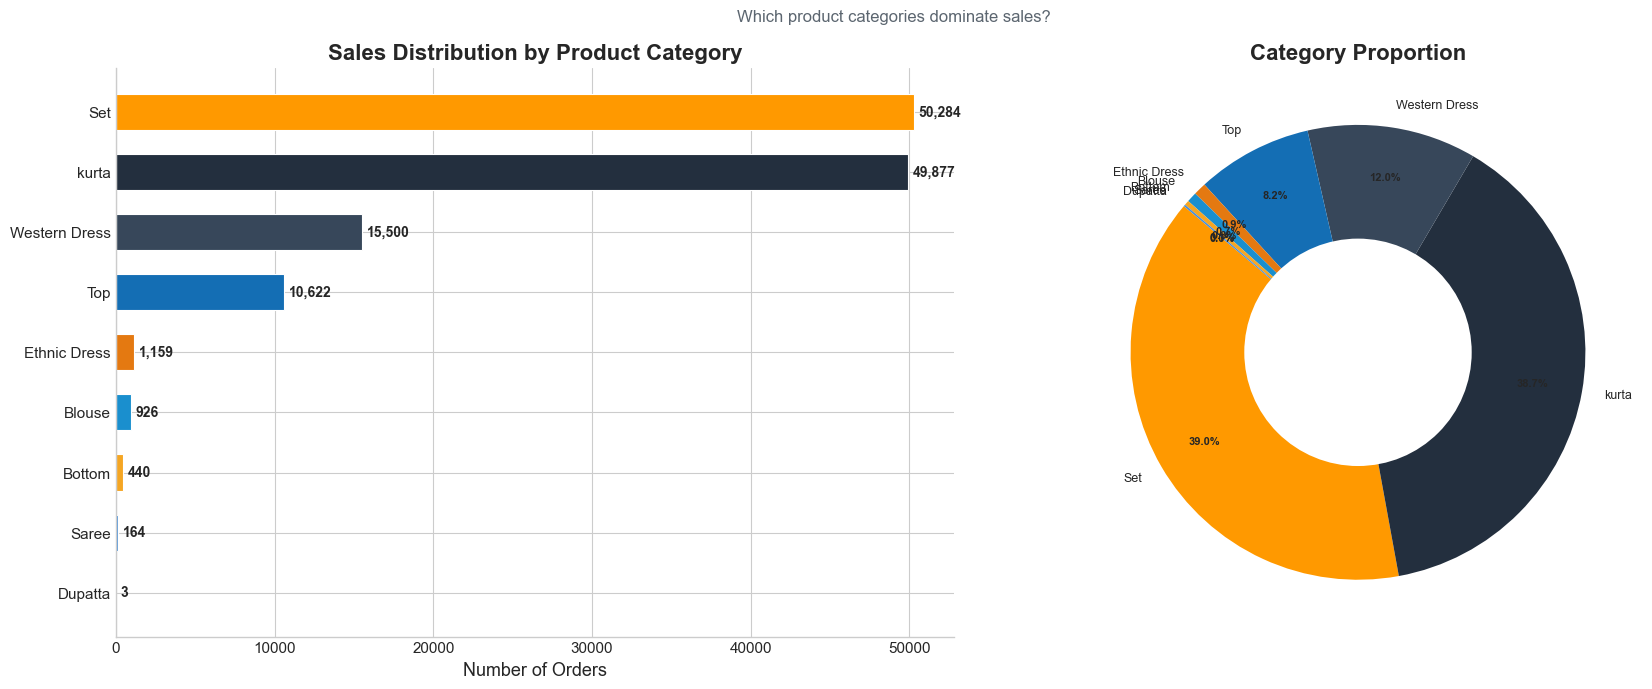


Top Category: Set with 50,284 orders (39.0%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cat_counts = df['Category'].value_counts()

colors_bar = PALETTE[:len(cat_counts)]
bars = axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
                     color=colors_bar[::-1], edgecolor='white', linewidth=0.8, height=0.6)
for bar in bars:
    width = bar.get_width()
    axes[0].text(width + 300, bar.get_y() + bar.get_height()/2,
                 f'{int(width):,}', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Sales Distribution by Product Category', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

wedges, texts, autotexts = axes[1].pie(
    cat_counts.values, labels=cat_counts.index,
    autopct='%1.1f%%', colors=colors_bar,
    startangle=140, pctdistance=0.78,
    textprops={'fontsize': 9}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Category Proportion', fontsize=16, fontweight='bold')

plt.suptitle('Which product categories dominate sales?', fontsize=12, y=0.98, color='#5C6670')
plt.tight_layout()
plt.show()

print(f'\nTop Category: {cat_counts.index[0]} with {cat_counts.values[0]:,} orders ({cat_counts.values[0]/len(df)*100:.1f}%)')

## 5. Product Size vs Quantity Sold

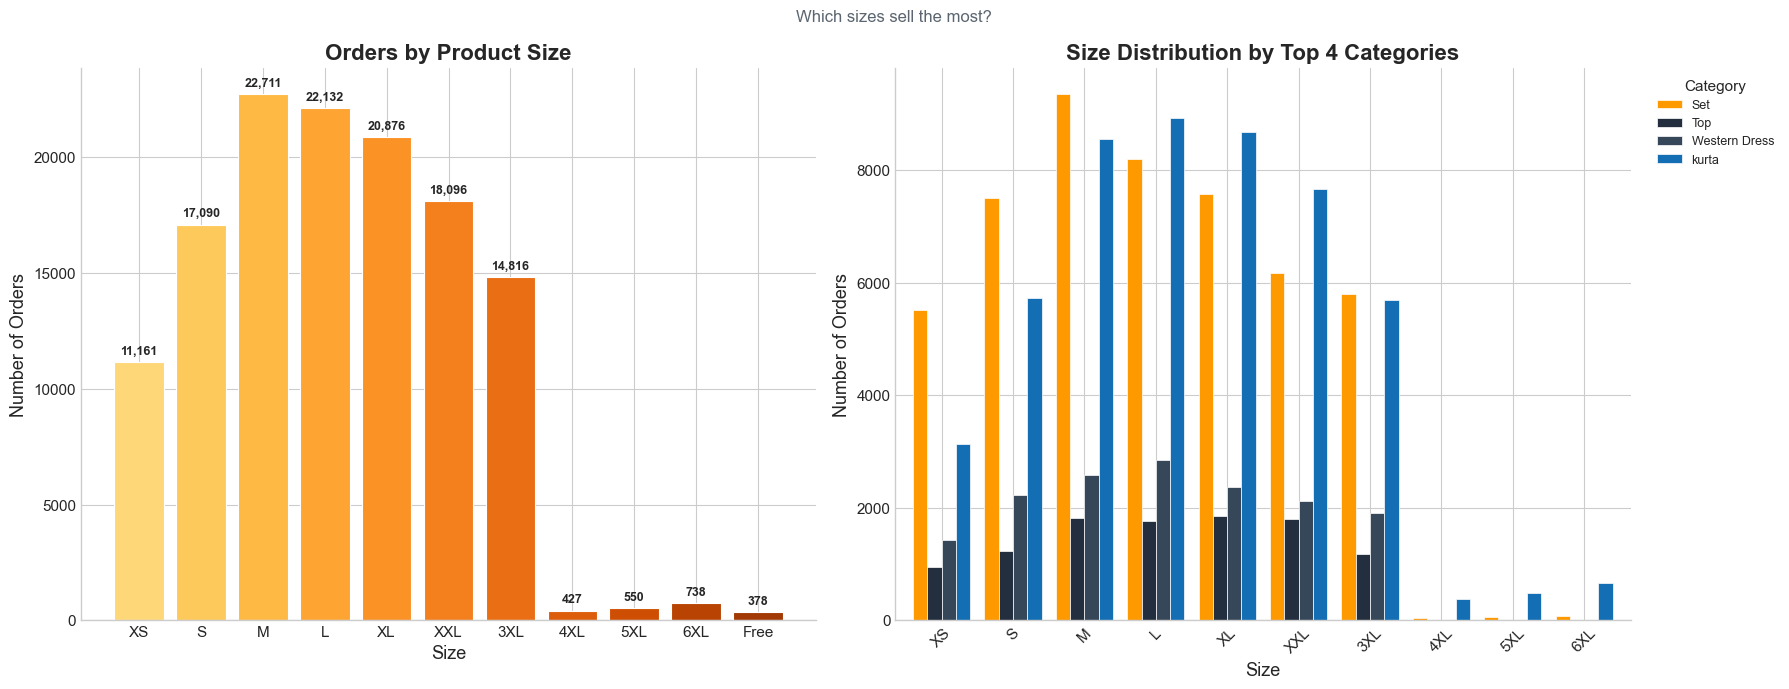


Most Popular Size: M with 22,711 orders


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'Free']
size_counts = df['Size'].value_counts().reindex(size_order).dropna()

gradient_colors = plt.cm.YlOrBr(np.linspace(0.3, 0.85, len(size_counts)))
bars = axes[0].bar(size_counts.index, size_counts.values,
                    color=gradient_colors, edgecolor='white', linewidth=0.8)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 200,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Orders by Product Size', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Size')
axes[0].set_ylabel('Number of Orders')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

top_cats = df['Category'].value_counts().head(4).index.tolist()
size_cat = df[df['Category'].isin(top_cats)].groupby(['Size', 'Category']).size().unstack(fill_value=0)
size_cat = size_cat.reindex([s for s in size_order if s in size_cat.index])
size_cat.plot(kind='bar', ax=axes[1], color=PALETTE[:4], edgecolor='white', linewidth=0.5, width=0.8)
axes[1].set_title('Size Distribution by Top 4 Categories', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Size')
axes[1].set_ylabel('Number of Orders')
axes[1].legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Which sizes sell the most?', fontsize=12, y=0.98, color='#5C6670')
plt.tight_layout()
plt.show()

print(f'\nMost Popular Size: {df["Size"].value_counts().index[0]} with {df["Size"].value_counts().values[0]:,} orders')

## 6. Courier Status Impact on Delivery

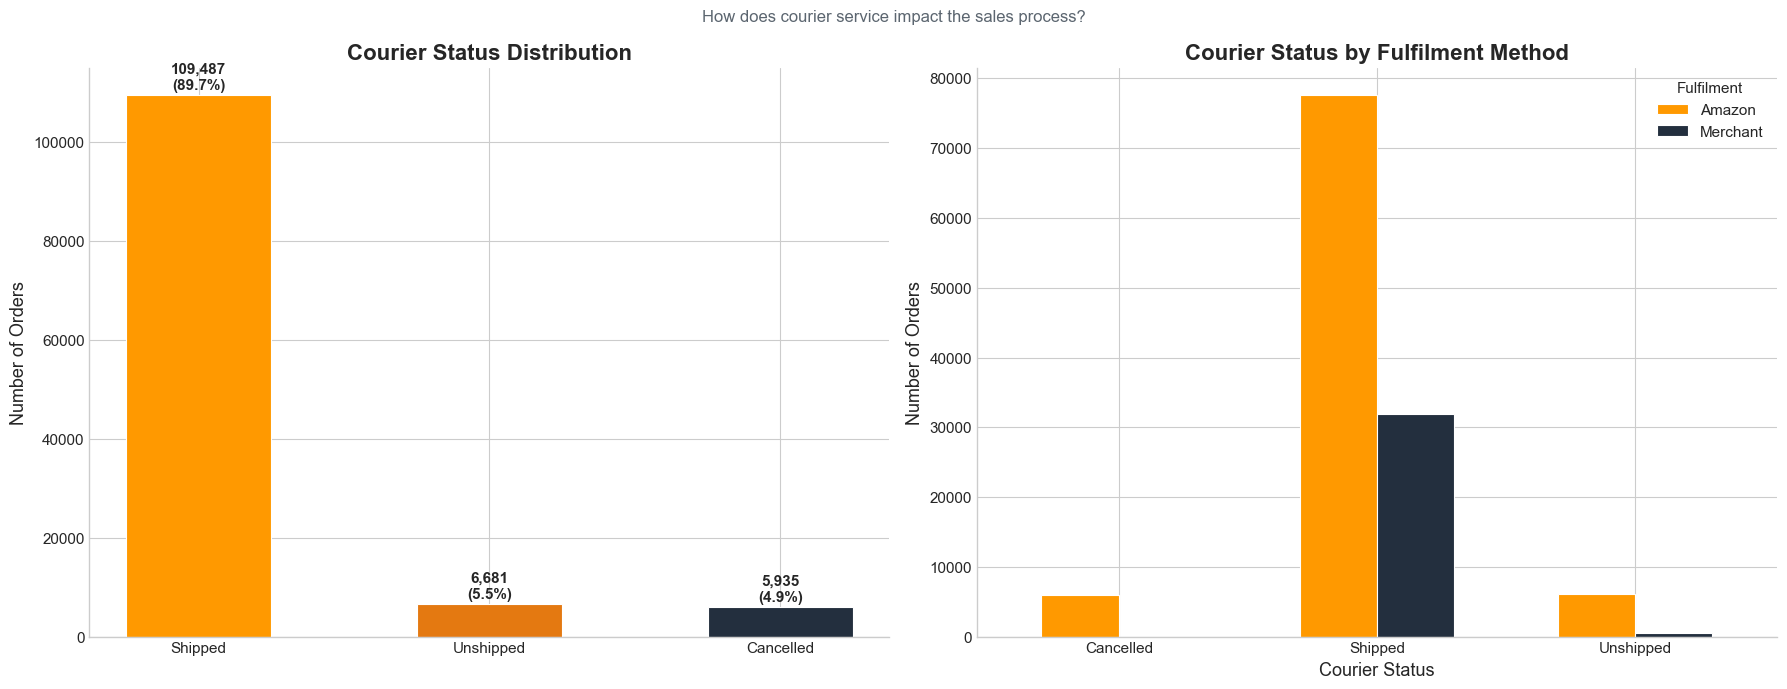


Shipped Rate: 89.7%
Cancelled by Courier: 5,935 orders


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

courier_counts = df[df['Courier Status'] != 'Unknown']['Courier Status'].value_counts()
courier_colors = ['#FF9900', '#E47911', '#232F3E']

bars = axes[0].bar(courier_counts.index, courier_counts.values,
                    color=courier_colors[:len(courier_counts)],
                    edgecolor='white', linewidth=0.8, width=0.5)
for bar in bars:
    height = bar.get_height()
    pct = height / courier_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 500,
                 f'{int(height):,}\n({pct:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Courier Status Distribution', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

courier_ful = pd.crosstab(df[df['Courier Status'] != 'Unknown']['Courier Status'],
                           df[df['Courier Status'] != 'Unknown']['Fulfilment'])
courier_ful.plot(kind='bar', ax=axes[1], color=['#FF9900', '#232F3E'],
                  edgecolor='white', linewidth=0.8, width=0.6)
axes[1].set_title('Courier Status by Fulfilment Method', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Courier Status')
axes[1].set_ylabel('Number of Orders')
axes[1].legend(title='Fulfilment', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('How does courier service impact the sales process?', fontsize=12, y=0.98, color='#5C6670')
plt.tight_layout()
plt.show()

shipped_pct = courier_counts.get('Shipped', 0) / courier_counts.sum() * 100
print(f'\nShipped Rate: {shipped_pct:.1f}%')
print(f'Cancelled by Courier: {courier_counts.get("Cancelled", 0):,} orders')

## 7. Order Status Analysis

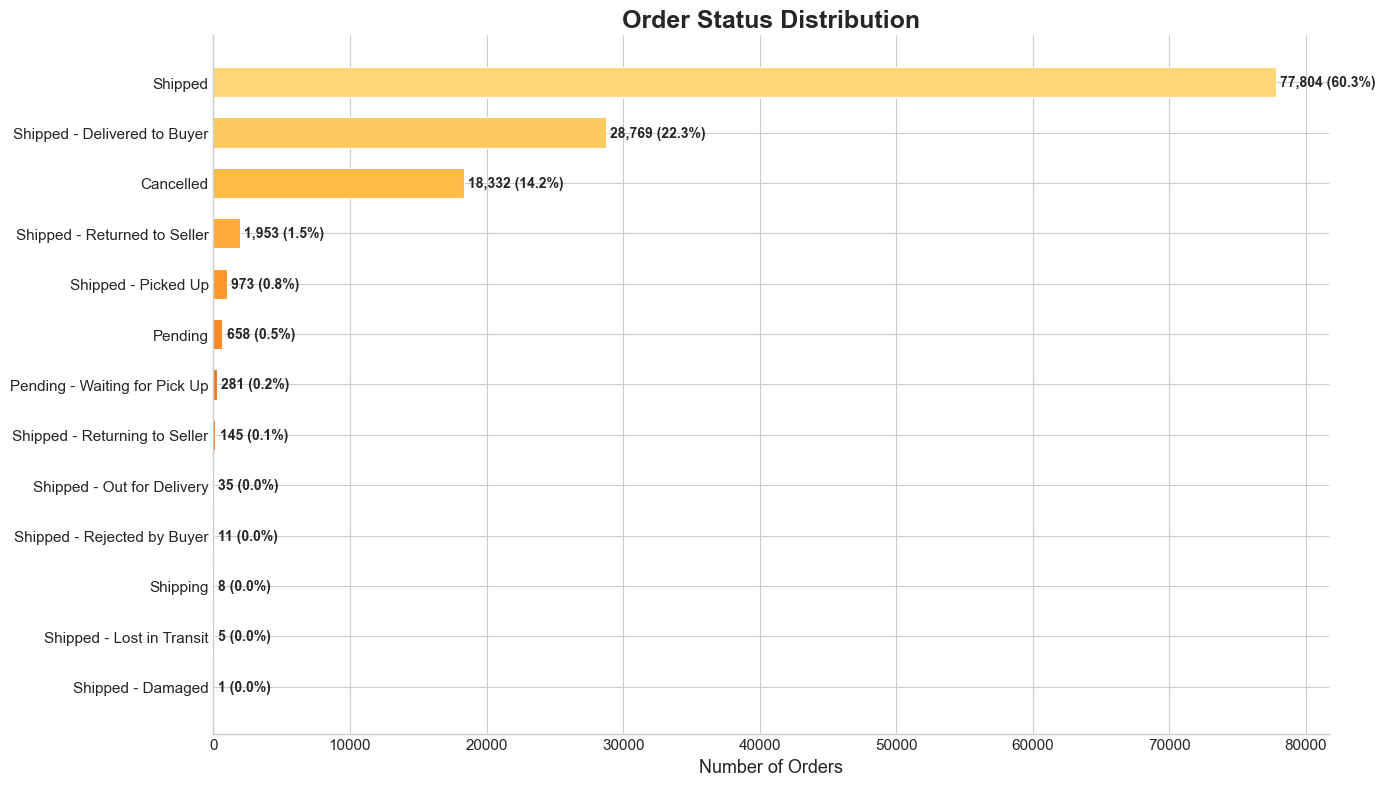

Cancellation Rate: 14.21%
Delivered Rate: 22.31%


In [8]:
fig, ax = plt.subplots(figsize=(14, 8))

status_counts = df['Status'].value_counts()

colors_grad = plt.cm.YlOrBr(np.linspace(0.3, 0.9, len(status_counts)))[::-1]
bars = ax.barh(status_counts.index[::-1], status_counts.values[::-1],
                color=colors_grad, edgecolor='white', linewidth=0.8, height=0.6)

for bar in bars:
    width = bar.get_width()
    pct = width / len(df) * 100
    ax.text(width + 300, bar.get_y() + bar.get_height()/2,
            f'{int(width):,} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')

ax.set_title('Order Status Distribution', fontsize=18, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

cancel_rate = (df['Status'] == 'Cancelled').sum() / len(df) * 100
delivered_rate = (df['Status'] == 'Shipped - Delivered to Buyer').sum() / len(df) * 100
print(f'Cancellation Rate: {cancel_rate:.2f}%')
print(f'Delivered Rate: {delivered_rate:.2f}%')

## 8. State-wise Distribution & Shipping Status

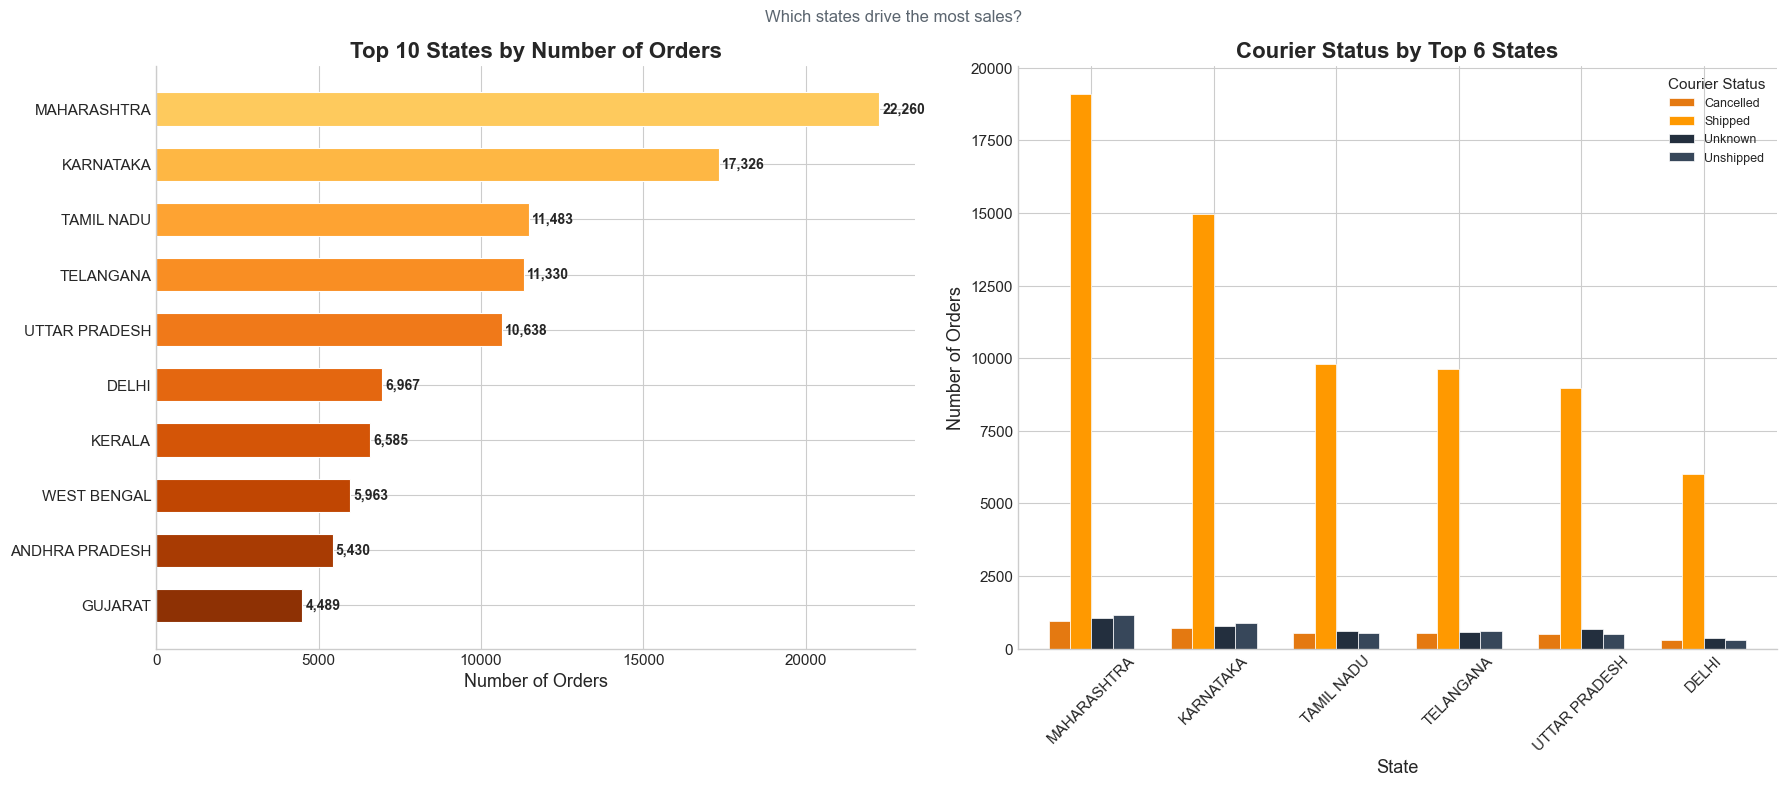


Top State: MAHARASHTRA with 22,260 orders


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

state_counts = df['ship-state'].value_counts().head(10)

gradient_colors = plt.cm.YlOrBr(np.linspace(0.35, 0.9, 10))[::-1]
bars = axes[0].barh(state_counts.index[::-1], state_counts.values[::-1],
                     color=gradient_colors, edgecolor='white', linewidth=0.8, height=0.6)
for bar in bars:
    width = bar.get_width()
    axes[0].text(width + 100, bar.get_y() + bar.get_height()/2,
                 f'{int(width):,}', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Top 10 States by Number of Orders', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Orders')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

top_states = state_counts.index[:6].tolist()
state_courier = df[df['ship-state'].isin(top_states)].groupby(
    ['ship-state', 'Courier Status']).size().unstack(fill_value=0)
state_courier = state_courier.reindex(top_states)
state_courier.plot(kind='bar', ax=axes[1],
                    color=['#E47911', '#FF9900', '#232F3E', '#37475A'],
                    edgecolor='white', linewidth=0.5, width=0.7)
axes[1].set_title('Courier Status by Top 6 States', fontsize=16, fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Number of Orders')
axes[1].legend(title='Courier Status', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Which states drive the most sales?', fontsize=12, y=0.98, color='#5C6670')
plt.tight_layout()
plt.show()

print(f'\nTop State: {state_counts.index[0]} with {state_counts.values[0]:,} orders')

## 9. City-wise Sales Analysis

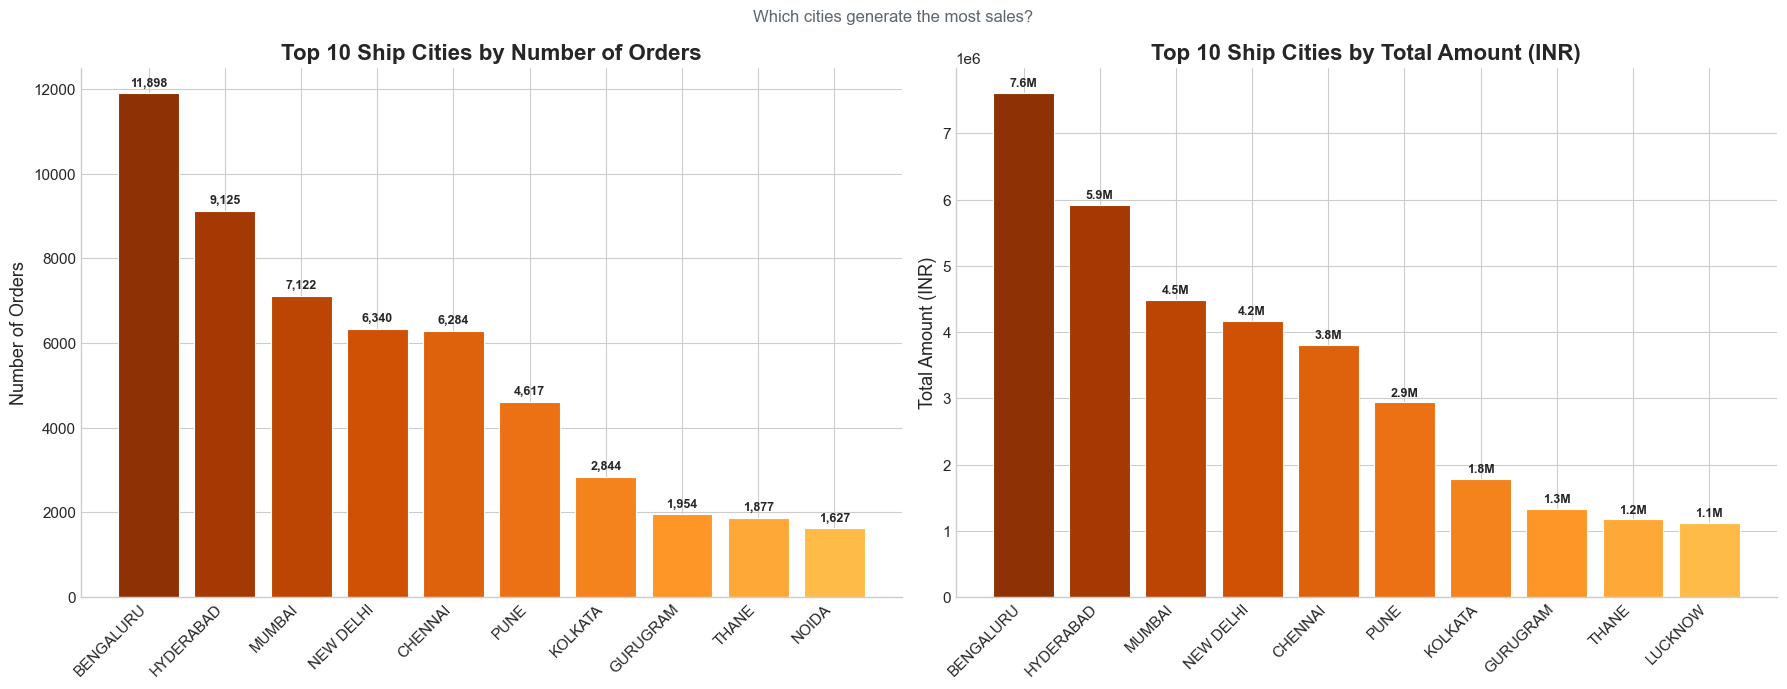

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

city_counts = df['ship-city'].value_counts().head(10)

gradient_colors = plt.cm.YlOrBr(np.linspace(0.4, 0.9, 10))[::-1]
bars = axes[0].bar(range(len(city_counts)), city_counts.values,
                    color=gradient_colors, edgecolor='white', linewidth=0.8)
axes[0].set_xticks(range(len(city_counts)))
axes[0].set_xticklabels(city_counts.index, rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 100,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Top 10 Ship Cities by Number of Orders', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

city_amount = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)
bars2 = axes[1].bar(range(len(city_amount)), city_amount.values,
                     color=gradient_colors, edgecolor='white', linewidth=0.8)
axes[1].set_xticks(range(len(city_amount)))
axes[1].set_xticklabels(city_amount.index, rotation=45, ha='right')
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 50000,
                 f'{height/1e6:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Top 10 Ship Cities by Total Amount (INR)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Total Amount (INR)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Which cities generate the most sales?', fontsize=12, y=0.98, color='#5C6670')
plt.tight_layout()
plt.show()

## 10. B2B vs B2C Analysis

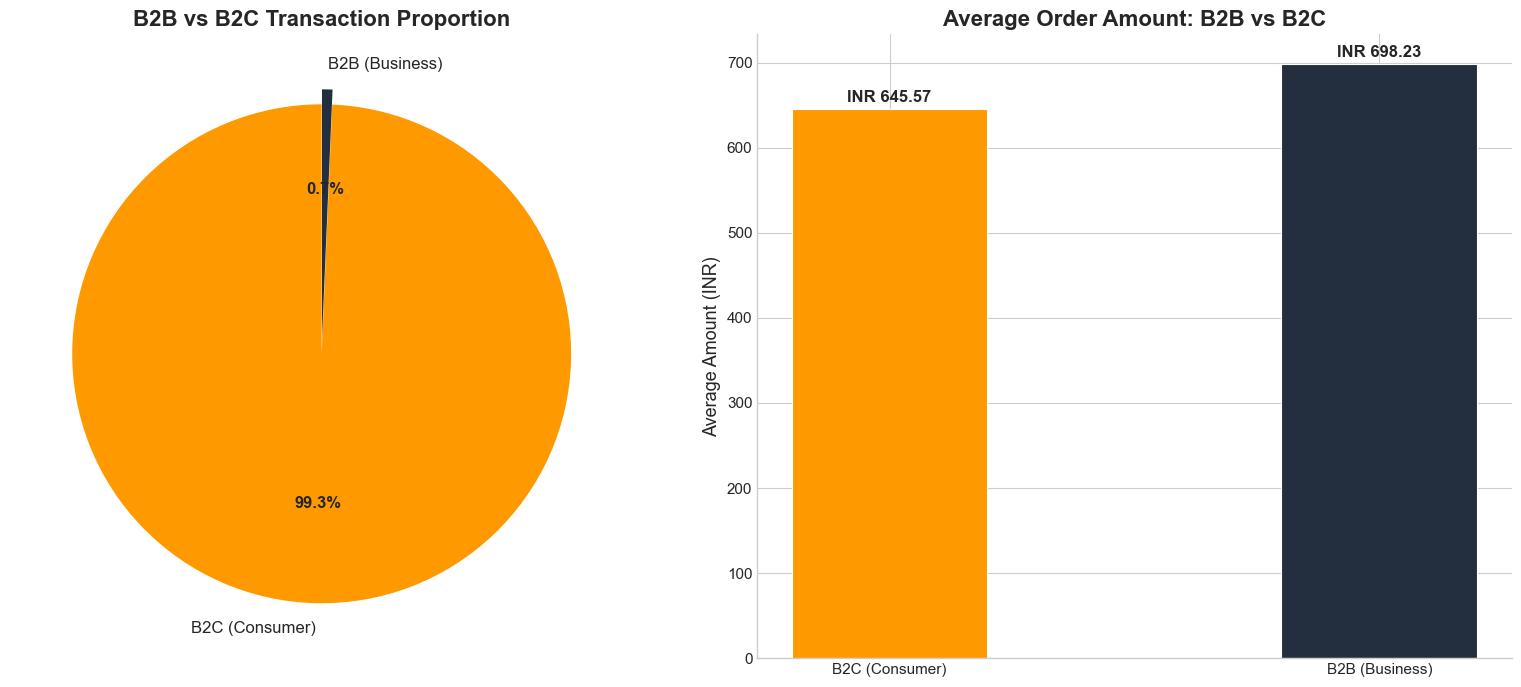


B2B Transactions: 871 (0.68%)
B2C Transactions: 128,104 (99.32%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

b2b_counts = df['B2B'].value_counts()
labels = ['B2C (Consumer)', 'B2B (Business)']

wedges, texts, autotexts = axes[0].pie(
    b2b_counts.values, labels=labels,
    autopct='%1.1f%%', colors=['#FF9900', '#232F3E'],
    startangle=90, explode=(0.03, 0.03),
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[0].set_title('B2B vs B2C Transaction Proportion', fontsize=16, fontweight='bold')

b2b_amount = df.groupby('B2B')['Amount'].mean()
bars = axes[1].bar(labels, b2b_amount.values,
                    color=['#FF9900', '#232F3E'],
                    edgecolor='white', linewidth=0.8, width=0.4)
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 5,
                 f'INR {height:,.2f}', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[1].set_title('Average Order Amount: B2B vs B2C', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Average Amount (INR)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

b2b_total = (df['B2B'] == True).sum()
print(f'\nB2B Transactions: {b2b_total:,} ({b2b_total/len(df)*100:.2f}%)')
print(f'B2C Transactions: {len(df) - b2b_total:,} ({(len(df) - b2b_total)/len(df)*100:.2f}%)')

## 11. Fulfilment Analysis (Amazon vs Merchant)

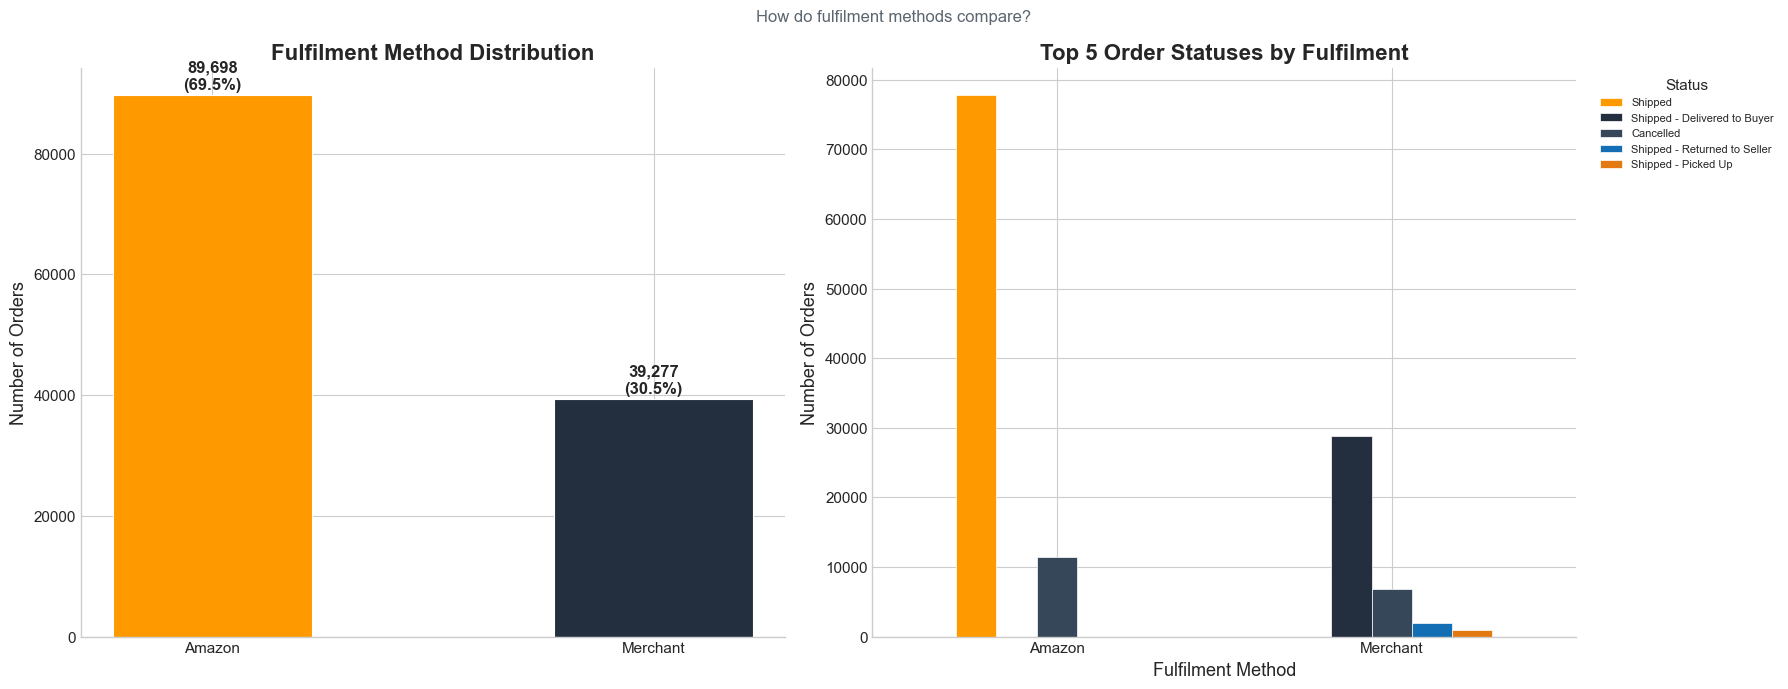

Amazon Cancel Rate: 12.79%
Merchant Cancel Rate: 17.47%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ful_counts = df['Fulfilment'].value_counts()

bars = axes[0].bar(ful_counts.index, ful_counts.values,
                    color=['#FF9900', '#232F3E'],
                    edgecolor='white', linewidth=0.8, width=0.45)
for bar in bars:
    height = bar.get_height()
    pct = height / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 500,
                 f'{int(height):,}\n({pct:.1f}%)', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
axes[0].set_title('Fulfilment Method Distribution', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

top_statuses = df['Status'].value_counts().head(5).index.tolist()
ful_status = pd.crosstab(df['Fulfilment'], df['Status'])[top_statuses]
ful_status.plot(kind='bar', ax=axes[1], color=PALETTE[:5],
                 edgecolor='white', linewidth=0.5, width=0.6)
axes[1].set_title('Top 5 Order Statuses by Fulfilment', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Fulfilment Method')
axes[1].set_ylabel('Number of Orders')
axes[1].legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('How do fulfilment methods compare?', fontsize=12, y=0.98, color='#5C6670')
plt.tight_layout()
plt.show()

amazon_cancel = df[(df['Fulfilment'] == 'Amazon') & (df['Status'] == 'Cancelled')].shape[0]
merchant_cancel = df[(df['Fulfilment'] == 'Merchant') & (df['Status'] == 'Cancelled')].shape[0]
amazon_total = (df['Fulfilment'] == 'Amazon').sum()
merchant_total = (df['Fulfilment'] == 'Merchant').sum()
print(f'Amazon Cancel Rate: {amazon_cancel/amazon_total*100:.2f}%')
print(f'Merchant Cancel Rate: {merchant_cancel/merchant_total*100:.2f}%')

## 12. Summary & Suggestions

In [13]:
print('=' * 65)
print('  AMAZON SALES REPORT - SUMMARY OF FINDINGS')
print('=' * 65)

print(f'''
DATASET OVERVIEW
  Total Data Analyzed  : {len(df):,} transactions
  Total Revenue        : INR {df["Amount"].sum():,.2f}
  Average Order Value  : INR {df["Amount"].mean():,.2f}
  Date Range           : {df["Date"].min().date()} to {df["Date"].max().date()}
''')

print(f'''KEY FINDINGS
  Top Category         : {df["Category"].value_counts().index[0]} ({df["Category"].value_counts().values[0]:,} orders)
  Most Popular Size    : {df["Size"].value_counts().index[0]}
  Top Ship City        : {df["ship-city"].value_counts().index[0]} ({df["ship-city"].value_counts().values[0]:,} orders)
  Top Ship State       : {df["ship-state"].value_counts().index[0]} ({df["ship-state"].value_counts().values[0]:,} orders)
  Cancellation Rate    : {(df["Status"]=="Cancelled").sum()/len(df)*100:.2f}%
  B2B Proportion       : {(df["B2B"]==True).sum()/len(df)*100:.2f}%
  Amazon Fulfilment    : {(df["Fulfilment"]=="Amazon").sum()/len(df)*100:.2f}%
''')

print('=' * 65)
print('  SUGGESTIONS')
print('=' * 65)

print('''
  1. Set dan Kurta mendominasi penjualan. Fokus inventory
     dan marketing pada kedua kategori ini untuk
     memaksimalkan revenue.

  2. Ukuran M, L, dan XL paling banyak terjual. Pastikan
     stok ukuran ini selalu tersedia di warehouse.

  3. Bengaluru, Hyderabad, dan Mumbai adalah 3 kota teratas.
     Prioritaskan distribusi dan promosi di kota-kota ini.

  4. Maharashtra dan Karnataka adalah state dengan order
     terbanyak. Pertimbangkan warehouse tambahan di area ini
     untuk mempercepat pengiriman.

  5. Cancellation rate perlu ditekan lebih rendah. Analisis
     lebih lanjut penyebab pembatalan untuk meningkatkan
     konversi penjualan.

  6. Amazon Fulfilment menangani mayoritas order dan perlu
     dievaluasi efektivitasnya dibandingkan Merchant
     fulfilment untuk peningkatan layanan.
''')

  AMAZON SALES REPORT - SUMMARY OF FINDINGS

DATASET OVERVIEW
  Total Data Analyzed  : 128,975 transactions
  Total Revenue        : INR 83,308,653.30
  Average Order Value  : INR 645.93
  Date Range           : 2022-03-31 to 2022-06-29

KEY FINDINGS
  Top Category         : Set (50,284 orders)
  Most Popular Size    : M
  Top Ship City        : BENGALURU (11,898 orders)
  Top Ship State       : MAHARASHTRA (22,260 orders)
  Cancellation Rate    : 14.21%
  B2B Proportion       : 0.68%
  Amazon Fulfilment    : 69.55%

  SUGGESTIONS

  1. Set dan Kurta mendominasi penjualan. Fokus inventory
     dan marketing pada kedua kategori ini untuk
     memaksimalkan revenue.

  2. Ukuran M, L, dan XL paling banyak terjual. Pastikan
     stok ukuran ini selalu tersedia di warehouse.

  3. Bengaluru, Hyderabad, dan Mumbai adalah 3 kota teratas.
     Prioritaskan distribusi dan promosi di kota-kota ini.

  4. Maharashtra dan Karnataka adalah state dengan order
     terbanyak. Pertimbangkan warehouse